In [1]:
import sys
sys.path.append('../..')
from datasets import load_dataset, load_dataset_builder

from astropile.utils import cross_match_datasets
from photo_z_wrapper import PhotoZWrapper

In [8]:
# Load Dataset Builders 
#hsc_builder = load_dataset_builder('/mnt/ceph/users/polymathic/AstroPile_tiny/hsc/hsc.py', trust_remote_code=True)
#desi_builder = load_dataset_builder('/mnt/ceph/users/polymathic/AstroPile_tiny/desi/desi.py', trust_remote_code=True)

jwst = load_dataset('/Users/marchuertascompany/Documents/python_scripts/visualstudio/AstroPile_prototype/scripts/jwst', trust_remote_code=True)

# Cross-Match Datasets with AstroPile
#hsc_meets_desi = cross_match_datasets(desi_builder, hsc_builder,
                                    #  matching_radius=1.0,
                                    #  keep_in_memory=True,
                                    #  )

jwst.set_format('torch')

In [9]:
sys.path.append('../')
from utils import split_dataset

# Use prebuilt split function to split the dataset (currently supports naive)
train_dataset, test_dataset = split_dataset(jwst['train'], split='naive')

In [10]:
# Create PhotoZWrapper for training and testing
photo_z = PhotoZWrapper(
    train_dataset,
    test_dataset, 
    feature_flag='image.array', # feature flag
    label_flag='z_phot',             # label flag
    loading='iterated',         # iterated or full
    dynamic_range=True,         # arcsinh dynamic range compression
    batch_size=1, 
    num_workers=16, 
    test_size=0.2, 
    )    

In [11]:
# Prepare data before using the data loader
# This computes the statistics and sets up the collate functions correctly
photo_z.prepare_data()

/Users/marchuertascompany/Documents/python_scripts/visualstudio/AstroPile_prototype/baselines/photo_z/../utils.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dummy = torch.tensor(get_nested(dataset[0], flag))
Computing statistics for z_phot: 100%|██████████| 2/2 [00:14<00:00,  7.17s/it]


In [12]:
train_loader = photo_z.train_dataloader()
val_loader = photo_z.val_dataloader()
test_loader = photo_z.test_dataloader()

/Users/marchuertascompany/soft/miniforge3/envs/tfenv23/lib/python3.8/site-packages/torch/utils/data/dataloader.py:563: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [13]:
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([1, 6, 96, 96]), torch.Size([1]))

/var/folders/3b/tyyj2qy12lxcqm59_rgl14bh0000gn/T/ipykernel_99410/3390336676.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matricesor `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at  /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:2985.)
  plt.imshow(x[0,:3,:,:].T)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


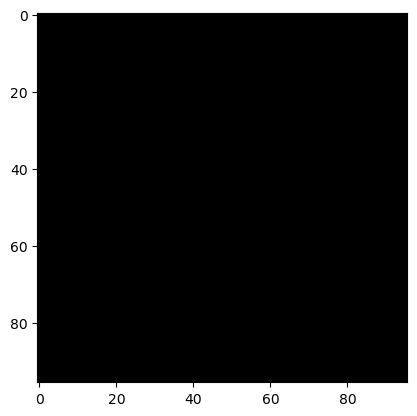

In [14]:
import matplotlib.pyplot as plt
plt.imshow(x[0,:3,:,:].T)